# Entendiendo el Dataset del VAST Challenge 2020

## 1. Formalización del dataset

El dataset del VAST Challenge 2020 puede modelarse como un **grafo multi-relacional, dirigido y temporal**:

$$
G = (V, E, T, \phi_V, \phi_E)
$$

donde:

* $V$: conjunto de nodos
* $E \subseteq V \times V$: conjunto de aristas dirigidas
* $T$: dimensión temporal (timestamps por edge)
* $\phi_V$: atributos de nodos (tipo, ubicación, etc.)
* $\phi_E$: atributos de aristas (tipo, peso, tiempo, localización)

Este grafo no es homogéneo: contiene **múltiples tipos de nodos y relaciones**, lo que lo convierte en un **grafo heterogéneo**.


## 2. Tipos de nodos (semántica estructural)

Existen 5 tipos de nodos:

| Tipo | Entidad            | Rol en el grafo                               |
| ---- | ------------------ | --------------------------------------------- |
| 1    | Person             | Nodo central (eje de todas las interacciones) |
| 2    | Product category   | Interacciones de compra/venta                 |
| 3    | Document           | Producción académica                          |
| 4    | Financial category | Perfil económico                              |
| 5    | Country            | Movilidad geográfica                          |

**Dato a resaltar:**
El nodo tipo **Person (tipo 1)** actúa como *hub semántico*, conectando todas las capas del grafo.


## 3. Tipos de relaciones (multi-relacionalidad)

Las aristas están definidas por `eType`:

| eType | Canal      | Significado     |
| ----- | ---------- | --------------- |
| 0     | Email      | Comunicación    |
| 1     | Phone      | Comunicación    |
| 2     | Sell       | Venta           |
| 3     | Buy        | Compra          |
| 4     | Author-of  | Publicación     |
| 5     | Financial  | Flujo económico |
| 6     | Travels-to | Viajes          |

Cada relación representa un **tipo de interacción distinta**, lo que implica:

* Diferente semántica
* Diferente distribución
* Diferente utilidad para el análisis

Esto define el grafo como **multi-relacional** 

## 4. Propiedades estructurales del grafo

El grafo presenta las siguientes características:

### 4.1 Dirigido

* Todas las aristas tienen dirección
* Ejemplo:

  * Person → Product
  * Person → Country


### 4.2 Parcialmente bipartito

Algunos canales conectan distintos tipos de nodos:

* Procurement: Person ↔ Product
* Travel: Person → Country

Esto introduce **estructura bipartita en subgrafos específicos**.


### 4.3 Multi-capa (multi-layer graph)

El dataset puede interpretarse como múltiples capas:

```text
Capa social       → Email, Phone
Capa económica    → Procurement, Financial
Capa académica    → Co-authorship
Capa geográfica   → Travel
```

Cada capa aporta información distinta sobre los nodos

## 5. Dimensión temporal

Cada arista tiene un timestamp:

* Tiempo en segundos desde 01/01/2025
* Permite analizar:

  * secuencias de eventos
  * patrones de actividad
  * correlaciones temporales

Casos importantes:

* Co-authorship → tiempos negativos (histórico)
* Demographics → tiempo fijo (snapshot)

✔ Esto implica que el grafo es **temporal no homogéneo**

## 6. Atributos relevantes

### 6.1 Peso (`Weight`)

* Comunicación → siempre 1
* Procurement → valor económico
* Co-authorship → fracción de contribución
* Travel → duración del viaje

### 6.2 Ubicación (ruidosa)

* Country (0–5)
* Latitud / Longitud

Importante:

* Datos con **ruido intencional**
* No representan ubicaciones reales

Esto afecta directamente el análisis geográfico

## 7. Naturaleza del problema (conexión con la tarea)

El objetivo del challenge no es solo analizar el grafo, sino:

"Encontrar subgrafos en los datos que coincidan (total o parcialmente) con un **template graph**"

Esto implica que el dataset debe entenderse en términos de:

### 7.1 Estructura

* patrones de conexión entre nodos

### 7.2 Temporalidad

* secuencia de eventos

### 7.3 Atributos

* perfiles económicos
* comportamiento de viaje


## 8. Implicaciones para el EDA

Dado lo anterior, el análisis exploratorio debe considerar:

* **Estructura del grafo** (topología)
* **Dinámica temporal**
* **Perfiles de nodos**
* **Relaciones entre capas**

No es suficiente un EDA tabular tradicional.


## 9. Dato crítico

El dataset no debe interpretarse como una tabla de registros, sino como: **un sistema complejo de interacciones multi-dimensionales donde el nodo “Person” actúa como entidad integradora de comportamiento social, económico y geográfico.**

Esto justifica que el análisis posterior se enfoque en:

* similitud estructural
* similitud temporal
* similitud de perfiles

## 10. Sintesis

El dataset del VAST Challenge 2020 constituye un **grafo heterogéneo, multi-relacional y temporal**, donde múltiples fuentes de información describen el comportamiento de individuos desde distintas perspectivas. Esta estructura compleja requiere un enfoque de análisis que combine:

* teoría de grafos
* análisis temporal
* comparación de perfiles

para poder abordar correctamente la tarea de replicación basada en matching de subgrafos.

# EDA

In [ ]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data")

graph_files = {
  "Template": "CGCS-Template.csv",
  "Q1_Graph1": "Q1-Graph1.csv",
  "Q1_Graph2": "Q1-Graph2.csv",
  "Q1_Graph3": "Q1-Graph3.csv",
  "Q1_Graph4": "Q1-Graph4.csv",
  "Q1_Graph5": "Q1-Graph5.csv",
}

seed_files = {
  "Q2_Seed1": "Q2-Seed1.csv",
  "Q2_Seed2": "Q2-Seed2.csv",
  "Q2_Seed3": "Q2-Seed3.csv",
}

metadata_files = {
  "graph_node_types": "CGCS-GraphData-NodeTypes.csv",
  "template_node_types": "CGCS-Template-NodeTypes.csv",
  "node_type_descriptions": "NodeTypeDescriptions.csv",
}

In [9]:
def load_existing(files_dict, data_dir=DATA_DIR):
  loaded = {}
  missing = []

  for name, filename in files_dict.items():
    path = data_dir / filename
    if path.exists():
      loaded[name] = pd.read_csv(path)
    else:
      missing.append(filename)

  return loaded, missing

In [10]:
graphs, missing_graphs = load_existing(graph_files)
seeds, missing_seeds = load_existing(seed_files)
metadata, missing_metadata = load_existing(metadata_files)

print("Loaded graphs:", list(graphs.keys()))
print("Missing graphs:", missing_graphs)

print("Loaded seeds:", list(seeds.keys()))
print("Missing seeds:", missing_seeds)

print("Loaded metadata:", list(metadata.keys()))
print("Missing metadata:", missing_metadata)

Loaded graphs: ['Template', 'Q1_Graph1', 'Q1_Graph2', 'Q1_Graph3', 'Q1_Graph4', 'Q1_Graph5']
Missing graphs: []
Loaded seeds: ['Q2_Seed1', 'Q2_Seed2', 'Q2_Seed3']
Missing seeds: []
Loaded metadata: ['graph_node_types', 'template_node_types', 'node_type_descriptions']
Missing metadata: []


No tenemos data faltante en los archivos proporcionados. Sin embargo, es importante destacar que el dataset ha sido intencionalmente modificado para incluir ruido, especialmente en las columnas de ubicación (Country, Latitud, Longitud). Esto significa que aunque no haya datos faltantes, la calidad de los datos en ciertas columnas puede ser baja, lo que podría afectar el análisis geográfico y la interpretación de los patrones de viaje. Por lo tanto, es crucial tener en cuenta esta limitación al realizar cualquier análisis o visualización basada en estas columnas.

In [ ]:
def inspect_dataset_collection(collection, collection_name):
  rows = []

  for name, df in collection.items():
    nodes = pd.unique(df[["Source", "Target"]].values.ravel()) \
      if {"Source", "Target"}.issubset(df.columns) else []

    rows.append({
      "collection": collection_name,
      "dataset": name,
      "rows": len(df),
      "columns": len(df.columns),
      "n_nodes": len(nodes),
      "n_eTypes": df["eType"].nunique() if "eType" in df.columns else None,
      "time_min": df["Time"].min() if "Time" in df.columns else None,
      "time_max": df["Time"].max() if "Time" in df.columns else None,
      "has_weight": "Weight" in df.columns,
      "has_location": any(c in df.columns for c in [
        "SourceLocation", "TargetLocation",
        "SourceLatitude", "SourceLongitude",
        "TargetLatitude", "TargetLongitude"
      ])
    })

  return pd.DataFrame(rows)

In [12]:
summary_graphs = inspect_dataset_collection(graphs, "candidate/template graphs")
summary_seeds = inspect_dataset_collection(seeds, "seed graphs")

summary_all = pd.concat([summary_graphs, summary_seeds], ignore_index=True)
summary_all

,collection,dataset,rows,columns,n_nodes,n_eTypes,time_min,time_max,has_weight,has_location
0,candidate/template graphs,Template,1325,11,88,7,-99,31536000,True,True
1,candidate/template graphs,Q1_Graph1,1216,11,93,7,-662041253,31536000,True,True
2,candidate/template graphs,Q1_Graph2,1300,11,87,7,-732727926,31536000,True,True
3,candidate/template graphs,Q1_Graph3,729,11,79,7,-209742644,31536000,True,True
4,candidate/template graphs,Q1_Graph4,732,11,87,6,98586,31536000,True,True
5,candidate/template graphs,Q1_Graph5,395,11,86,6,96346,31536000,True,True
6,seed graphs,Q2_Seed1,1,11,2,1,-685755382,-685755382,True,True
7,seed graphs,Q2_Seed2,1,11,2,1,-623491200,-623491200,True,True
8,seed graphs,Q2_Seed3,1,11,2,1,1991785,1991785,True,True


In [ ]:
import matplotlib.pyplot as plt

etype_labels = {
  0: "Email",
  1: "Phone",
  2: "Sell",
  3: "Buy",
  4: "Author-of",
  5: "Financial",
  6: "Travels-to"
}

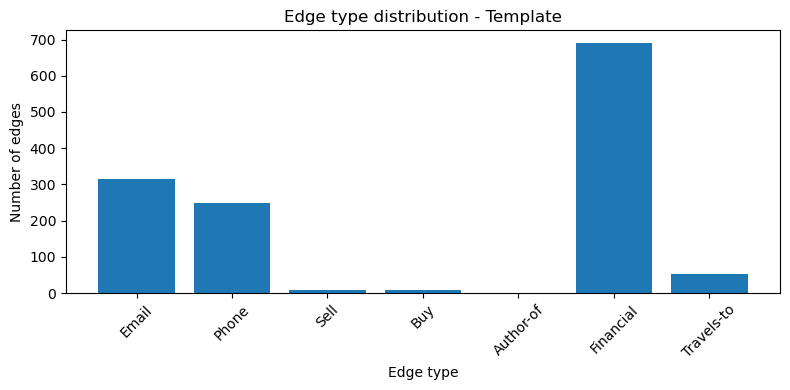

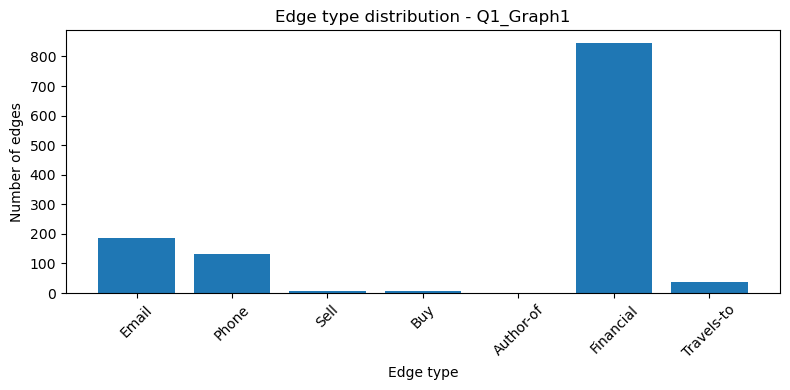

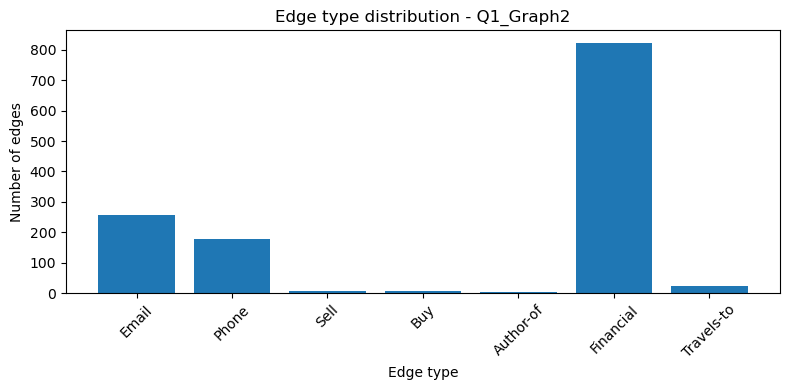

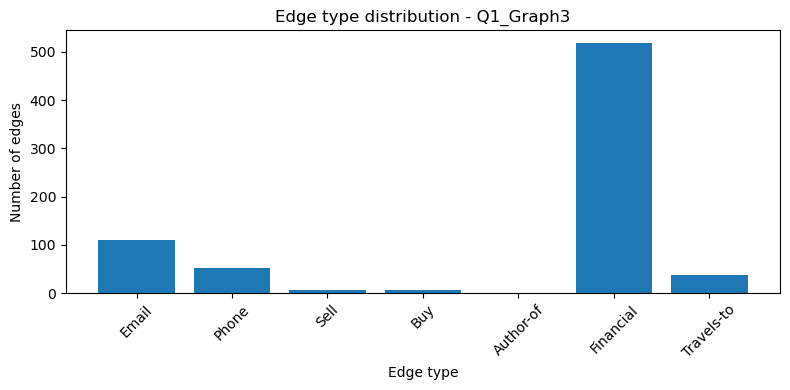

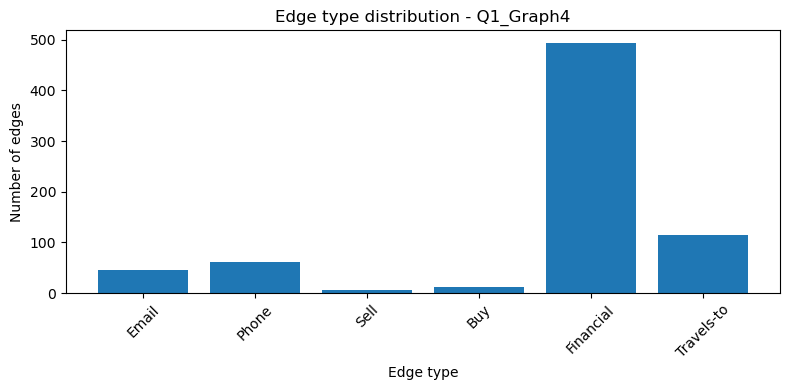

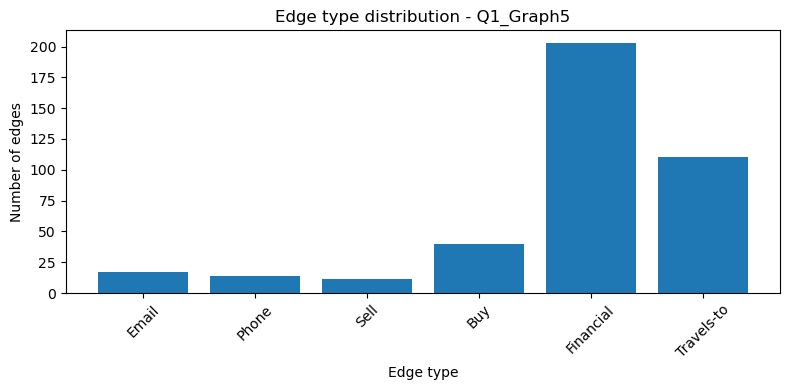

In [14]:
for name, df in graphs.items():
  counts = df["eType"].value_counts().sort_index()
  labels = [etype_labels.get(i, str(i)) for i in counts.index]

  plt.figure(figsize=(8, 4))
  plt.bar(labels, counts.values)
  plt.title(f"Edge type distribution - {name}")
  plt.xlabel("Edge type")
  plt.ylabel("Number of edges")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

Vemos que la mayoría de los grafos tienen una distribución de tipos de aristas bastante similar, con "Email" y "Phone" siendo los tipos más comunes, seguidos por "Sell", "Buy", "Author-of", "Financial" y "Travels-to". Sin embargo, algunos grafos pueden tener una mayor proporción de ciertos tipos de aristas, lo que podría indicar diferentes patrones de interacción entre los nodos en esos grafos específicos. Es importante tener en cuenta estas diferencias al analizar los grafos y al diseñar visualizaciones para representar las relaciones entre los nodos.

Vamos a empezar con la construción del grafo a partir de los datos proporcionados. Para esto, utilizaremos la librería `networkx` que es muy útil para trabajar con grafos en Python.

In [16]:
import networkx as nx

def build_graph(df):
  G = nx.DiGraph()
  
  for _, row in df.iterrows():
    G.add_edge(
      row["Source"],
      row["Target"],
      eType=row["eType"],
      time=row["Time"],
      weight=row.get("Weight", 1)
    )
    
  return G


graphs_nx = {name: build_graph(df) for name, df in graphs.items()}

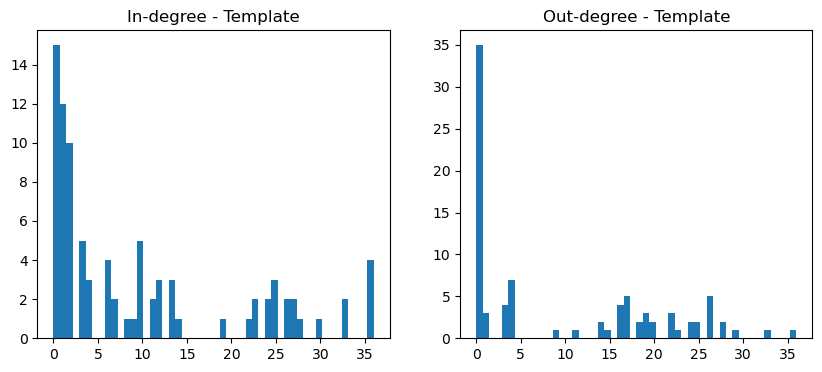

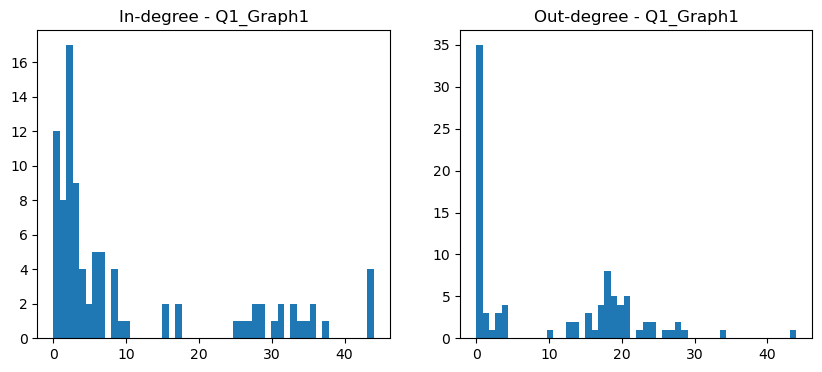

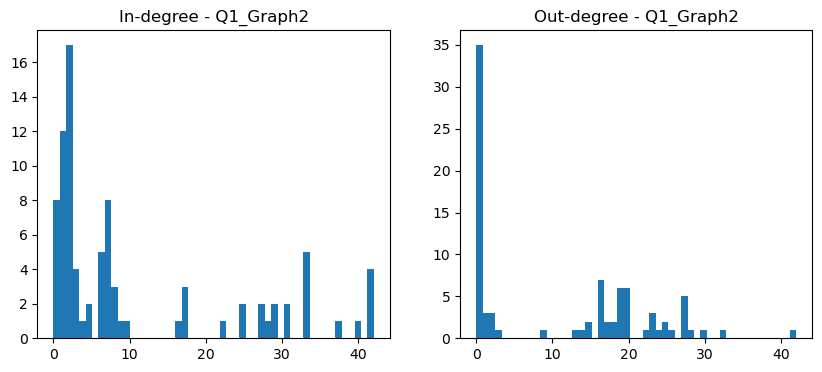

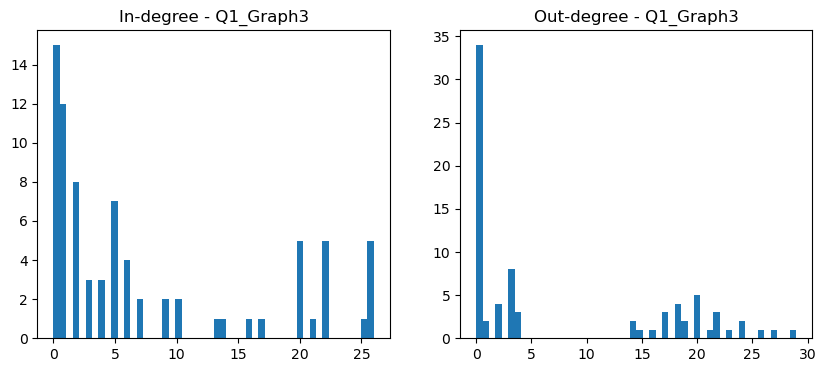

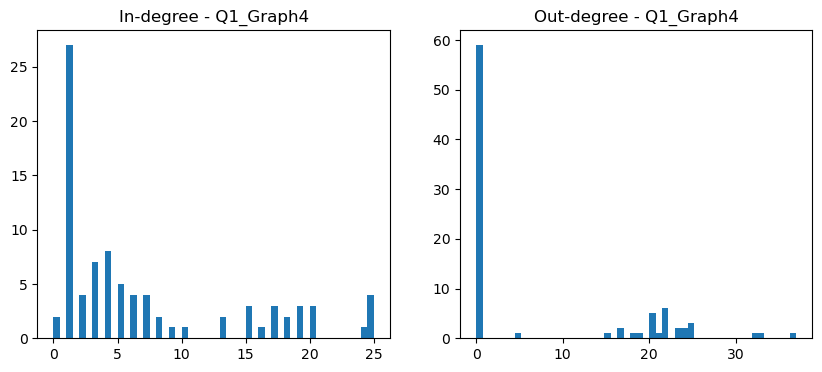

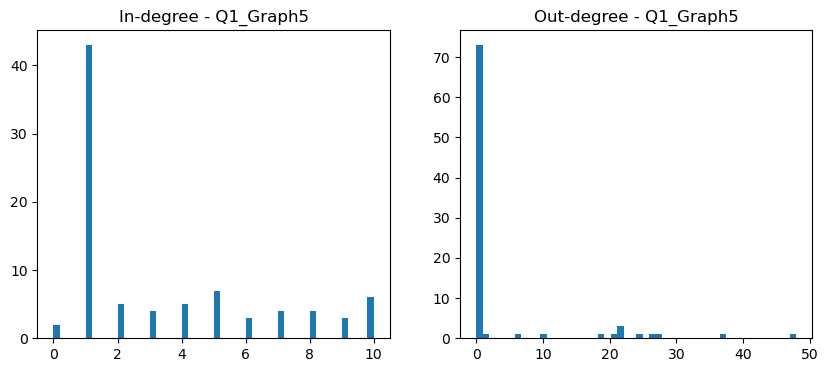

In [17]:
import matplotlib.pyplot as plt

for name, G in graphs_nx.items():
  in_deg = [d for _, d in G.in_degree()]
  out_deg = [d for _, d in G.out_degree()]
  
  plt.figure(figsize=(10,4))
  
  plt.subplot(1,2,1)
  plt.hist(in_deg, bins=50)
  plt.title(f"In-degree - {name}")
  
  plt.subplot(1,2,2)
  plt.hist(out_deg, bins=50)
  plt.title(f"Out-degree - {name}")
  
  plt.show()

El análisis de las distribuciones de grado (in-degree y out-degree) revela que todos los grafos presentan una estructura altamente asimétrica, caracterizada por una gran concentración de nodos con baja conectividad y una cola larga de nodos con grado elevado. Este comportamiento es consistente con redes complejas de tipo social o de comunicación, donde emergen nodos “hub” que concentran gran parte de las interacciones. 

Se observa además una clara asimetría entre in-degree y out-degree, con una fuerte concentración de valores cercanos a cero en el out-degree, lo que sugiere una estructura dirigida dominada por relaciones desde nodos tipo “Person” hacia otras entidades (productos, categorías, países). Esto refuerza la naturaleza parcialmente bipartita y multi-relacional del grafo, donde distintas capas (comunicación, economía y movilidad) contribuyen de manera heterogénea a la conectividad global.

En la comparación estructural, el template presenta una distribución más balanceada, con mayor presencia de nodos de grado medio y alto, lo que indica una estructura más cohesionada. En contraste, varios grafos candidatos muestran una mayor dispersión, con abundancia de nodos periféricos y menor densidad estructural. Sin embargo, algunos subgrafos como Q1_Graph2 y Q1_Graph3 exhiben patrones de conectividad más similares al template, destacando como candidatos más plausibles para el proceso de matching.

En conjunto, estos resultados evidencian que la similitud entre grafos no depende únicamente del tamaño o número de aristas, sino de la forma de su distribución de conectividad. Por tanto, la presencia de hubs, la asimetría direccional y la estructura de grados constituyen características clave que serán utilizadas en etapas posteriores para evaluar la similitud estructural con el template.

In [18]:
for name, G in graphs_nx.items():
  components = list(nx.weakly_connected_components(G))
  
  sizes = [len(c) for c in components]
  
  print(f"{name}")
  print(f"Total components: {len(components)}")
  print(f"Largest component size: {max(sizes)}")
  print("-"*30)

Template
Total components: 1
Largest component size: 88
------------------------------
Q1_Graph1
Total components: 1
Largest component size: 93
------------------------------
Q1_Graph2
Total components: 1
Largest component size: 87
------------------------------
Q1_Graph3
Total components: 1
Largest component size: 79
------------------------------
Q1_Graph4
Total components: 1
Largest component size: 87
------------------------------
Q1_Graph5
Total components: 1
Largest component size: 86
------------------------------


Todos los grafos presentan una única componente conexa, lo que indica estructuras globalmente cohesionadas; por tanto, la discriminación entre ellos debe basarse en propiedades estructurales más finas y no en conectividad.

In [19]:
for name, G in graphs_nx.items():
  density = nx.density(G)
  print(f"{name} density: {density}")

Template density: 0.11219958202716823
Q1_Graph1 density: 0.11442262739597943
Q1_Graph2 density: 0.1272387062282812
Q1_Graph3 density: 0.09834469328140215
Q1_Graph4 density: 0.08219727345629511
Q1_Graph5 density: 0.03898768809849521


Los grafos Q1_Graph1 y Q1_Graph2 presentan densidades más cercanas al template, lo que sugiere mayor similitud estructural, mientras que Q1_Graph5, con una densidad considerablemente menor, muestra una estructura más dispersa y menos comparable. Sin embargo, la densidad por sí sola no es suficiente para determinar similitud, por lo que debe complementarse con métricas locales y temporales.

In [20]:
def subgraph_by_etype(df, etype):
  return df[df["eType"] == etype]


etype_graphs = {}

for name, df in graphs.items():
  etype_graphs[name] = {}
  
  for etype in df["eType"].unique():
    sub_df = subgraph_by_etype(df, etype)
    etype_graphs[name][etype] = build_graph(sub_df)

eType legend (Edge Types)

0 → Email  
  Comunicación por correo entre personas

1 → Phone  
  Llamadas telefónicas entre personas

2 → Sell (Procurement)  
  Venta de un producto (Person → Product)

3 → Buy (Procurement)  
  Compra de un producto (Person → Product)

4 → Author-of (Co-authorship)  
  Relación de autoría (Person → Document)

5 → Financial (Demographics)  
  Flujo económico / atributos financieros  
  (gasto o ingreso en categorías)

6 → Travels-to  
  Viajes (Person → Country)

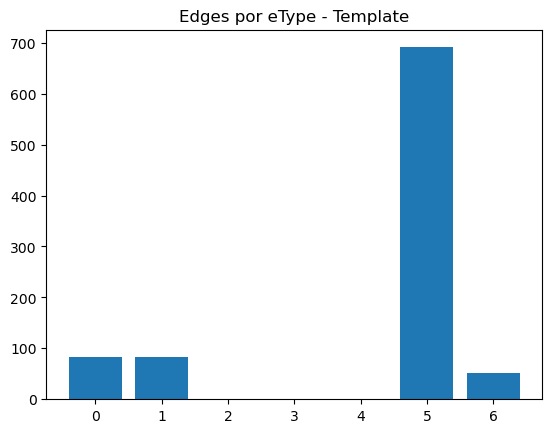

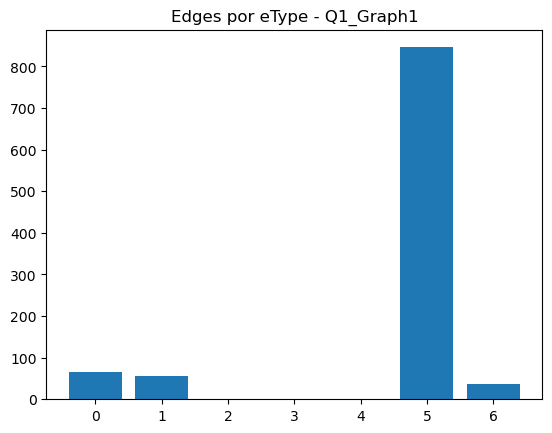

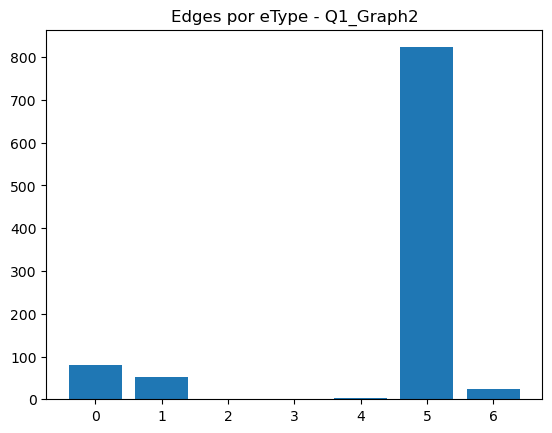

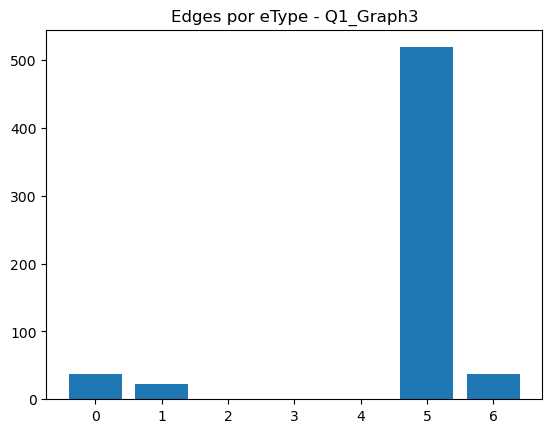

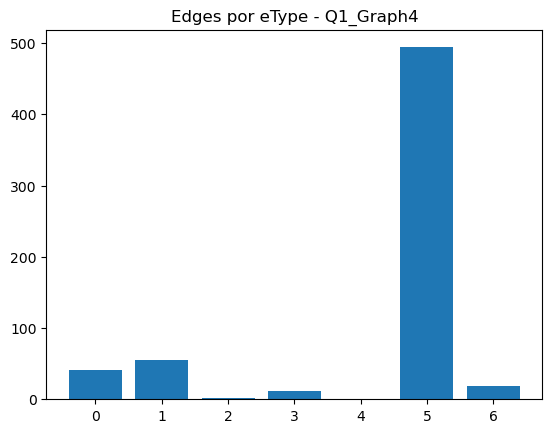

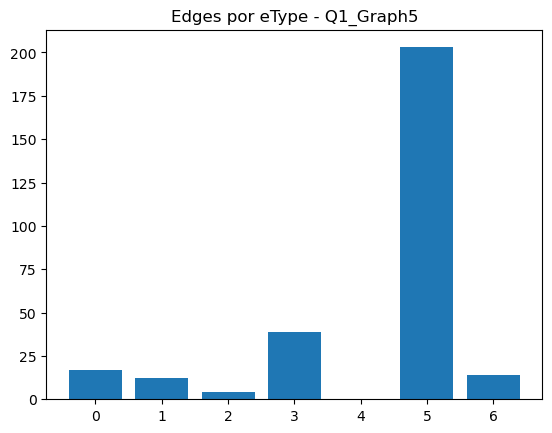

In [21]:
for name, subgraphs in etype_graphs.items():
  sizes = {etype: g.number_of_edges() for etype, g in subgraphs.items()}
  
  plt.bar(sizes.keys(), sizes.values())
  plt.title(f"Edges por eType - {name}")
  plt.show()

La estructura de los grafos está dominada por relaciones financieras, las cuales actúan como atributos densos, mientras que las relaciones de comunicación y viaje constituyen las principales fuentes de información estructural para el análisis de similitud. Por tanto, en etapas posteriores será necesario analizar por separado los distintos tipos de relaciones, o incluso filtrar aquellas que introducen alta densidad sin aportar conectividad significativa.

In [22]:
for name, G in graphs_nx.items():
  degree = dict(G.degree())
  
  top_nodes = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]
  
  print(f"\nTop nodes - {name}")
  print(top_nodes)


Top nodes - Template
[(np.float64(41.0), 47), (np.float64(45.0), 40), (np.float64(27.0), 38), (np.float64(47.0), 37), (np.float64(63.0), 37), (np.float64(43.0), 36), (np.float64(56.0), 36), (np.float64(552988.0), 36), (np.float64(527449.0), 36), (np.float64(459381.0), 36)]

Top nodes - Q1_Graph1
[(np.float64(635665.0), 49), (np.float64(552988.0), 44), (np.float64(527449.0), 44), (np.float64(459381.0), 44), (np.float64(595298.0), 44), (np.float64(473173.0), 44), (np.float64(620120.0), 44), (np.float64(503701.0), 37), (np.float64(599956.0), 36), (np.float64(567195.0), 36)]

Top nodes - Q1_Graph2
[(np.float64(629627.0), 49), (np.float64(552988.0), 42), (np.float64(527449.0), 42), (np.float64(459381.0), 42), (np.float64(595298.0), 42), (np.float64(473173.0), 42), (np.float64(620120.0), 42), (np.float64(466907.0), 40), (np.float64(585212.0), 37), (np.float64(503701.0), 37)]

Top nodes - Q1_Graph3
[(np.float64(538892.0), 34), (np.float64(541619.0), 34), (np.float64(500813.0), 30), (np.float

La coincidencia de nodos de alto grado entre el template y algunos grafos candidatos, junto con la similitud en sus niveles de centralidad, sugiere una correspondencia estructural directa que es clave para el proceso de matching. Cabe destacar que la presencia de hubs compartidos entre grafos no solo refleja similitud en la estructura global, sino también en los roles funcionales de los nodos dentro de la red.

Aca vamos a hacer una pequeña visualización de cada grafo para entender su estructura general. Dado que algunos grafos pueden ser muy grandes, limitaremos la visualización a aquellos con menos de 200 nodos para evitar un solapamiento visual excesivo. 

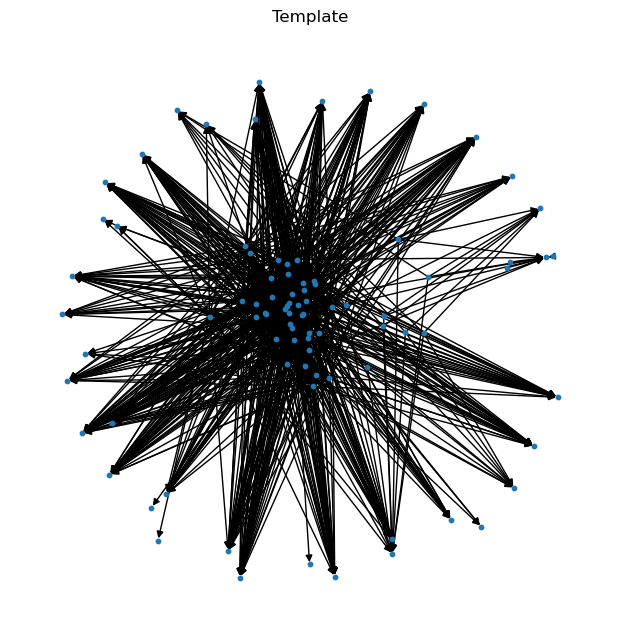

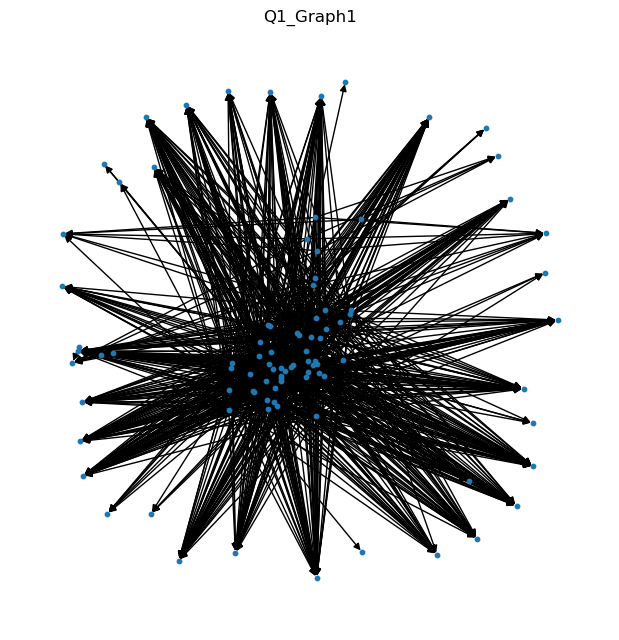

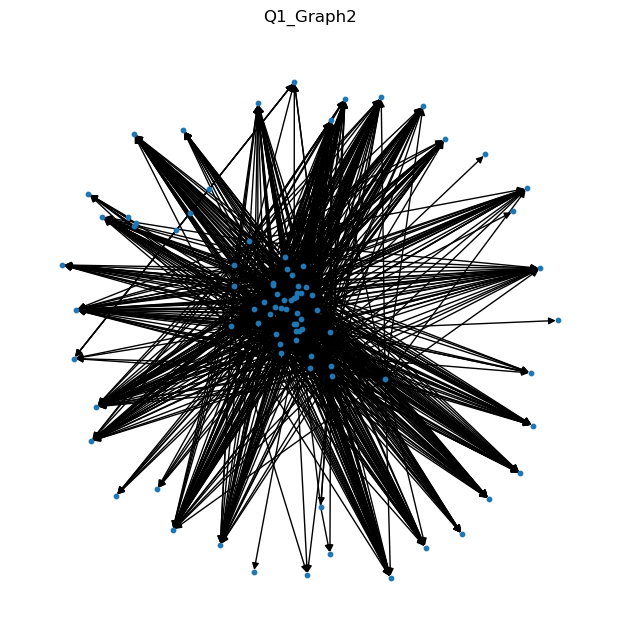

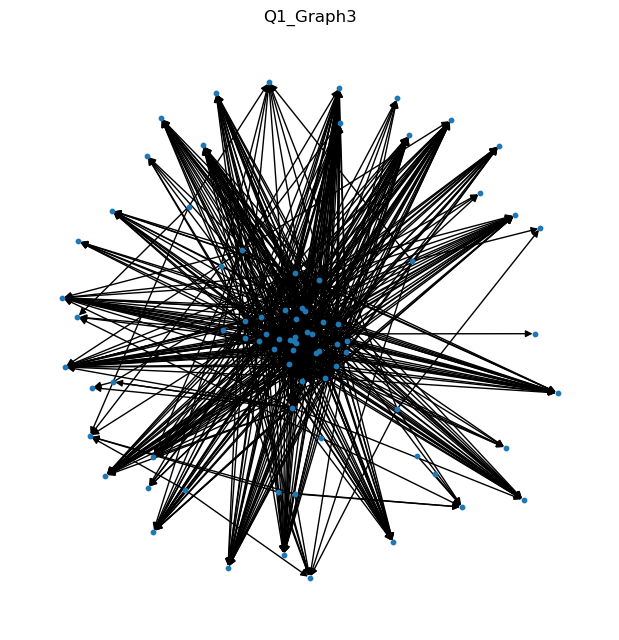

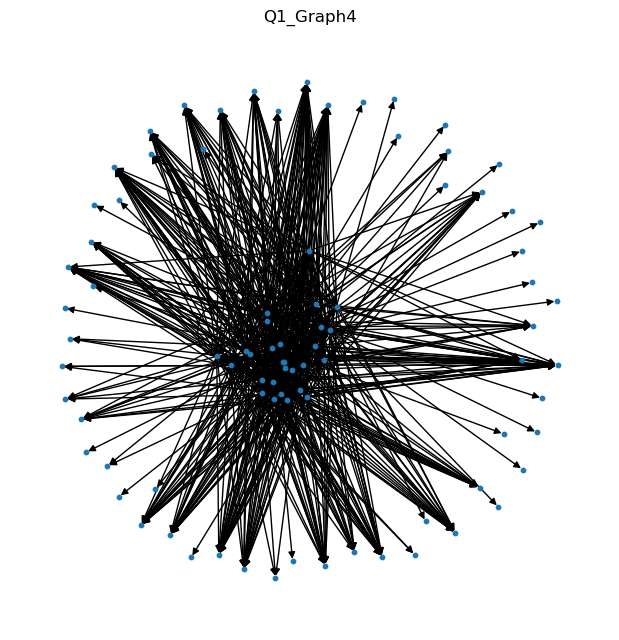

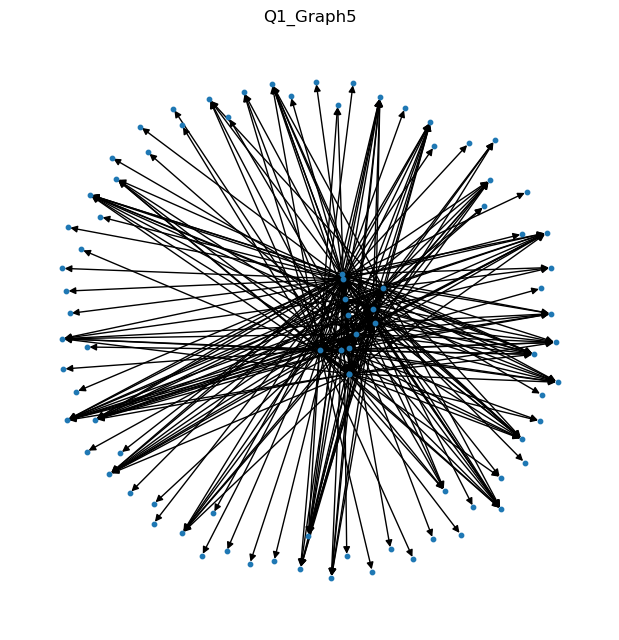

In [26]:
for name, G in graphs_nx.items():
  if G.number_of_nodes() < 200:
    plt.figure(figsize=(6,6))
    nx.draw(G, node_size=10)
    plt.title(name)
    plt.show()

La visualización de los grafos mediante diagramas node-link revela una estructura altamente centralizada en todos los casos, caracterizada por un núcleo denso de nodos interconectados rodeado de múltiples nodos periféricos. Este patrón es consistente con la presencia de hubs identificados previamente en el análisis de grado.

En el template, se observa una estructura relativamente balanceada, donde el núcleo central está compuesto por varios nodos con alta conectividad, distribuyendo las relaciones de manera más homogénea. Este patrón se replica de forma muy similar en Q1_Graph1 y Q1_Graph2, donde se aprecia un núcleo compacto y múltiples conexiones radiales hacia nodos periféricos, lo que sugiere una organización interna comparable.

Por otro lado, Q1_Graph3 mantiene una estructura similar pero con menor densidad en el núcleo, lo que indica una red menos cohesionada. Q1_Graph4 presenta una disposición más dispersa, con menor concentración en el centro, mientras que Q1_Graph5 exhibe una estructura claramente desbalanceada, donde un conjunto reducido de nodos domina la conectividad, generando una forma más irregular y menos distribuida.

Es importante señalar que este tipo de visualización tiene limitaciones para el análisis cuantitativo, especialmente en grafos densos, donde la superposición de aristas dificulta la interpretación detallada. Sin embargo, a nivel global permite identificar patrones de centralización, cohesión y distribución de nodos que complementan los análisis previos basados en métricas estructurales.

En el contexto del problema de matching, estas observaciones refuerzan la similitud estructural entre el template y Q1_Graph1/Q1_Graph2, mientras que grafos con estructuras más dispersas o desbalanceadas presentan menor correspondencia con el patrón objetivo.

Debido a la alta densidad de aristas, estas visualizaciones deben interpretarse como una referencia cualitativa, siendo necesario complementarlas con métricas estructurales para un análisis riguroso.

In [34]:
def export_graph_for_d3(df, name):
  nodes = pd.DataFrame({
    "id": pd.unique(df[["Source", "Target"]].values.ravel())
  })
  
  edges = df[["Source", "Target", "eType", "Time"]]
  
  nodes.to_csv(f"nodes_{name}.csv", index=False)
  edges.to_csv(f"edges_{name}.csv", index=False)


for name, df in graphs.items():
  export_graph_for_d3(df, name)

Parte comparativa y de feature engineering para el matching

In [27]:
import numpy as np

def compute_graph_features(name, G, df):
  degrees = np.array([d for _, d in G.degree()])
  
  return {
    "graph": name,
    "n_nodes": G.number_of_nodes(),
    "n_edges": G.number_of_edges(),
    "density": nx.density(G),
    "avg_degree": degrees.mean(),
    "max_degree": degrees.max(),
    "std_degree": degrees.std(),
    "n_eTypes": df["eType"].nunique(),
  }

features = []

for name in graphs:
  features.append(
    compute_graph_features(name, graphs_nx[name], graphs[name])
  )

features_df = pd.DataFrame(features)
features_df

,graph,n_nodes,n_edges,density,avg_degree,max_degree,std_degree,n_eTypes
0,Template,88,859,0.112200,19.522727,47,12.185104,7
1,Q1_Graph1,93,979,0.114423,21.053763,49,12.391782,7
2,Q1_Graph2,87,952,0.127239,21.885057,49,12.341338,7
3,Q1_Graph3,79,606,0.098345,15.341772,34,9.850639,7
4,Q1_Graph4,87,615,0.082197,14.137931,41,11.771944,6
5,Q1_Graph5,86,285,0.038988,6.627907,52,9.816984,6


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

feature_cols = ["density", "avg_degree", "max_degree", "std_degree"]

X = scaler.fit_transform(features_df[feature_cols])

features_df_scaled = pd.DataFrame(X, columns=feature_cols)
features_df_scaled["graph"] = features_df["graph"]

In [29]:
from scipy.spatial.distance import cdist

template_vec = features_df_scaled[features_df_scaled["graph"] == "Template"][feature_cols].values

distances = cdist(
  features_df_scaled[feature_cols].values,
  template_vec,
  metric="euclidean"
)

features_df["distance_to_template"] = distances
features_df.sort_values("distance_to_template")

,graph,n_nodes,n_edges,density,avg_degree,max_degree,std_degree,n_eTypes,distance_to_template
0,Template,88,859,0.112200,19.522727,47,12.185104,7,0.000000
1,Q1_Graph1,93,979,0.114423,21.053763,49,12.391782,7,0.484292
2,Q1_Graph2,87,952,0.127239,21.885057,49,12.341338,7,0.776656
4,Q1_Graph4,87,615,0.082197,14.137931,41,11.771944,6,1.803617
3,Q1_Graph3,79,606,0.098345,15.341772,34,9.850639,7,3.129735
5,Q1_Graph5,86,285,0.038988,6.627907,52,9.816984,6,4.202471


In [30]:
def etype_distribution(df):
  counts = df["eType"].value_counts(normalize=True).sort_index()
  return counts.reindex(range(7), fill_value=0)

etype_features = []

for name, df in graphs.items():
  dist = etype_distribution(df)
  dist["graph"] = name
  etype_features.append(dist)

etype_df = pd.DataFrame(etype_features)
etype_df

eType,0,1,2,3,4,5,6,graph
proportion,0.236981,0.187925,0.006792,0.006792,0.000755,0.521509,0.039245,Template
proportion,0.153783,0.107730,0.005757,0.005757,0.000822,0.695724,0.030428,Q1_Graph1
proportion,0.198462,0.136154,0.005385,0.005385,0.003077,0.633077,0.018462,Q1_Graph2
proportion,0.149520,0.069959,0.008230,0.008230,0.001372,0.711934,0.050754,Q1_Graph3
proportion,0.061475,0.083333,0.006831,0.016393,0.000000,0.674863,0.157104,Q1_Graph4
proportion,0.043038,0.035443,0.027848,0.101266,0.000000,0.513924,0.278481,Q1_Graph5


In [31]:
template_vec = etype_df[etype_df["graph"] == "Template"].drop(columns=["graph"]).values

distances = cdist(
  etype_df.drop(columns=["graph"]).values,
  template_vec,
  metric="cosine"
)

etype_df["etype_distance"] = distances
etype_df.sort_values("etype_distance")

eType,0,1,2,3,4,5,6,graph,etype_distance
proportion,0.236981,0.187925,0.006792,0.006792,0.000755,0.521509,0.039245,Template,0.000000
proportion,0.198462,0.136154,0.005385,0.005385,0.003077,0.633077,0.018462,Q1_Graph2,0.014253
proportion,0.153783,0.107730,0.005757,0.005757,0.000822,0.695724,0.030428,Q1_Graph1,0.034503
proportion,0.149520,0.069959,0.008230,0.008230,0.001372,0.711934,0.050754,Q1_Graph3,0.046830
proportion,0.061475,0.083333,0.006831,0.016393,0.000000,0.674863,0.157104,Q1_Graph4,0.082546
proportion,0.043038,0.035443,0.027848,0.101266,0.000000,0.513924,0.278481,Q1_Graph5,0.176831


In [32]:
filtered_graphs = {
  name: df[df["eType"] != 5]
  for name, df in graphs.items()
}

In [33]:
final = features_df.merge(
  etype_df[["graph", "etype_distance"]],
  on="graph"
)

final["score"] = final["distance_to_template"] + final["etype_distance"]

final.sort_values("score")

,graph,n_nodes,n_edges,density,avg_degree,max_degree,std_degree,n_eTypes,distance_to_template,etype_distance,score
0,Template,88,859,0.112200,19.522727,47,12.185104,7,0.000000,0.000000,0.000000
1,Q1_Graph1,93,979,0.114423,21.053763,49,12.391782,7,0.484292,0.034503,0.518795
2,Q1_Graph2,87,952,0.127239,21.885057,49,12.341338,7,0.776656,0.014253,0.790909
4,Q1_Graph4,87,615,0.082197,14.137931,41,11.771944,6,1.803617,0.082546,1.886163
3,Q1_Graph3,79,606,0.098345,15.341772,34,9.850639,7,3.129735,0.046830,3.176565
5,Q1_Graph5,86,285,0.038988,6.627907,52,9.816984,6,4.202471,0.176831,4.379302
